# Fooling LIME — Ataques Adversariales a Métodos de Explicación Post Hoc

**Basado en:** Slack, D., Hilgard, S., Jia, E., Singh, S., & Lakkaraju, H. (2020). *Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods.* AAAI/ACM Conference on AI, Ethics, and Society (AIES).




## Idea Central del Paper

Los métodos de explicación post hoc como LIME P funcionan perturbando la entrada alrededor de una instancia para entender qué features importan. El problema es que estas perturbaciones generan puntos fuera de la distribución real de los datos.

Un adversario puede explotar esto construyendo un clasificador scaffold (andamiaje) que:
1. Detecta si una instancia viene de la distribución real (in-distribution) o es una perturbación (out-of-distribution).
2. Para datos reales → usa el modelo sesgado $f$ (ej: discrimina por raza).
3. Para perturbaciones → usa un modelo inocuo $\psi$ (ej: clasifica por una columna irrelevante).

Resultado: LIME explican el modelo inocuo $\psi$, mientras que en la práctica el modelo sesgado $f$ es el que toma las decisiones reales. El sesgo queda oculto.



## Diagrama del Ataque — Clasificador Scaffold

```mermaid
flowchart TD
    USER["Usuario consulta  <br/> con dato real x"]
    LIME["LIME consulta <br/> con perturbaciones de x"]
    OOD{"Detector OOD<br/>Random Forest"}
    F["Modelo Sesgado f<br/>usa race_African-American"]
    PSI["Modelo Inocuo psi<br/> usa random_noise"]
    R1["Prediccion sesgada<br/> en producción"]
    R2["Explicacion inocua<br/> LIME en monitoreo "]

    USER -->|dato real| OOD
    LIME -.->|perturbaciones| OOD
    OOD -->|In-distribution| F
    OOD -->|Out-of-distribution| PSI
    F --> R1
    PSI -.-> R2

    style USER fill:#6C9BD2,stroke:#4A7FB5,color:#fff,stroke-width:2px
    style LIME fill:#B39DDB,stroke:#7E57C2,color:#fff,stroke-width:2px
    style OOD fill:#F0C05A,stroke:#D4A537,color:#3E2723,stroke-width:2px
    style F fill:#E08B8B,stroke:#C0392B,color:#fff,stroke-width:2px
    style PSI fill:#7BC8A4,stroke:#27AE60,color:#fff,stroke-width:2px
    style R1 fill:#E08B8B,stroke:#C0392B,color:#fff,stroke-width:1px
    style R2 fill:#7BC8A4,stroke:#27AE60,color:#fff,stroke-width:1px
```



In [ ]:
# ==========================================
# 1. IMPORTACIONES
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import lime
import lime.lime_tabular

from copy import deepcopy


Importaciones completadas


## 2. Funciones Utilitarias

Reimplementamos las funciones de prepocesamiento 

In [ ]:
# ==========================================
# 2. FUNCIONES UTILITARIAS (de utils.py)
# ==========================================

def one_hot_encode(y):
    """Convierte predicciones binarias (0/1) a formato one-hot [[1,0], [0,1], ...]
    Necesario para que los modelos f y ψ tengan interfaz predict_proba."""
    y_hat_one_hot = np.zeros((len(y), 2))
    y_hat_one_hot[np.arange(len(y)), y] = 1
    return y_hat_one_hot

def rank_features(explanation):
    """Dada una explicación [(nombre, valor), ...], devuelve los nombres
    ordenados por importancia absoluta."""
    ordered_tuples = sorted(explanation, key=lambda x: abs(x[1]), reverse=True)
    results = [tup[0] if tup[1] != 0 else ("Nothing shown", 0) for tup in ordered_tuples]
    return results

def get_rank_map(ranks, to_consider):
    """Mapa de posición → [(feature, %ocurrencia), ...]"""
    unique = {i + 1: [] for i in range(len(ranks))}
    for i, rank in enumerate(ranks):
        for unique_rank in np.unique(rank):
            unique[i + 1].append((unique_rank, np.sum(np.array(rank) == unique_rank) / to_consider))
    return unique


def experiment_summary(explanations, features):
    """Resumen: para las top-3 posiciones, ¿qué features aparecen y con qué frecuencia?"""
    top_features = [[], [], []]
    for exp in explanations:
        ranks = rank_features(exp)
        for i in range(3):
            for f in features + ["Nothing shown"]:
                if f in ranks[i]:
                    top_features[i].append(f)
    return get_rank_map(top_features, len(explanations))


print("Funciones utilitarias definidas ✓")

Funciones utilitarias definidas ✓


## 3. Preprocesamiento COMPAS

Cargamos directamente el archivo compas_preprocessed.csv(ya preprocesado en el notebook 01) y aplicamos el mismo esquema de features. Usamos la columna random_noise feature del modelo inocuo $\psi$.

In [23]:
# ==========================================
# 3. PREPROCESAMIENTO COMPAS
# ==========================================
# El modelo inocuo ψ usará 'random_noise' (ya existente) como feature.

POSITIVE_OUTCOME = 1   # No reincidió
NEGATIVE_OUTCOME = 0   # Reincidió
PROTECTED_CLASS = 1    # African-American = 1
UNPROTECTED_CLASS = 0
SEED = 42

np.random.seed(SEED)

# --- Lectura del CSV preprocesado ---
df_filtered = pd.read_csv("data/compas_preprocessed.csv")
print(f"Filas en el dataset preprocesado: {len(df_filtered)}")

# --- Variable objetivo: two_year_recid (idéntico al notebook 01) ---
y = df_filtered['two_year_recid'].astype(int).values

# --- Features (mismo esquema que notebook 01) ---
feature_cols = ['age', 'priors_count', 'length_of_stay']
cat_features_drop = ['sex', 'c_charge_degree']   # drop_first
cat_features_keep = ['race']                       # todas las dummies

X = df_filtered[feature_cols + cat_features_drop + cat_features_keep].copy()
X = pd.get_dummies(X, columns=cat_features_drop, drop_first=True)
X = pd.get_dummies(X, columns=cat_features_keep, drop_first=False)
X = X.fillna(0)

# --- Agregar random_noise (mismo que notebook 01) ---
# Esta columna cumple doble función:
#   - En el notebook 01: feature de control para verificar importancia
#   - Aquí: feature que el modelo inocuo ψ usará para "engañar" a LIME/SHAP
X['random_noise'] = np.random.rand(len(X))

features = X.columns.tolist()

print(f"\nFeatures ({len(features)}): {features}")
print(f"Shape X: {X.shape}")
print(f"Distribución y: {np.unique(y, return_counts=True)}")
print(f"\n% African-American: {X['race_African-American'].mean()*100:.1f}%")

Filas en el dataset preprocesado: 6172

Features (12): ['age', 'priors_count', 'length_of_stay', 'sex_Male', 'c_charge_degree_M', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'random_noise']
Shape X: (6172, 12)
Distribución y: (array([0, 1]), array([3363, 2809]))

% African-American: 51.4%


In [24]:
# Índices importantes para los modelos f y ψ
race_indc = features.index('race_African-American')
noise_indc = features.index('random_noise')

# Features categóricas (para LIME)
categorical_feature_name = [
    'sex_Male', 'c_charge_degree_M',
    'race_African-American', 'race_Asian', 'race_Caucasian',
    'race_Hispanic', 'race_Native American', 'race_Other',
]
categorical_feature_indcs = [features.index(c) for c in categorical_feature_name]

# Convertir a numpy array
X = X.values

print(f"Índice de 'race_African-American': {race_indc}")
print(f"Índice de 'random_noise': {noise_indc}")
print(f"Índices categóricos: {categorical_feature_indcs}")
print(f"Features: {features}")

Índice de 'race_African-American': 5
Índice de 'random_noise': 11
Índices categóricos: [3, 4, 5, 6, 7, 8, 9, 10]
Features: ['age', 'priors_count', 'length_of_stay', 'sex_Male', 'c_charge_degree_M', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'random_noise']


## 4. Definición de los Modelos $f$ y $\psi$

### Modelo sesgado $f$ (racist_model_f)
- Regla de decisió Si el acusado es afroamericano (race_African-American == 1) → resultado negativo (reincidió).
- Este es el modelo que realmente toma las decisiones. Es explícitamente racista.

### Modelo inocuo $\psi$ (innocuous_model_psi)
- Regla de decisión: Clasifica según random_noise (umbral 0.5).
- Este es el modelo que queremos que LIME expliquen en lugar del real.
- Como random_noise es ruido puro, las explicaciones no revelarían el sesgo racial.

In [25]:
# ==========================================
# 4. MODELOS f (sesgado) Y ψ (inocuo)
# ==========================================

class racist_model_f:
    """Modelo sesgado f: clasifica negativamente si race_African-American > 0.
    Este es el modelo que REALMENTE toma decisiones."""

    def predict(self, X):
        return np.array([
            NEGATIVE_OUTCOME if x[race_indc] > 0 else POSITIVE_OUTCOME
            for x in X
        ])

    def predict_proba(self, X):
        return one_hot_encode(self.predict(X))

    def score(self, X, y):
        return np.sum(self.predict(X) == y) / len(X)


class innocuous_model_psi:
    """Modelo inocuo ψ: clasifica según 'random_noise' (umbral > 0.5).
    Este es el modelo que queremos que LIME expliquen."""

    def predict(self, X):
        return np.array([
            NEGATIVE_OUTCOME if x[noise_indc] > 0.5 else POSITIVE_OUTCOME
            for x in X
        ])

    def predict_proba(self, X):
        return one_hot_encode(self.predict(X))

    def score(self, X, y):
        return np.sum(self.predict(X) == y) / len(X)


# Verificar que funcionan
print("Modelo sesgado f — predicción para 5 instancias:", racist_model_f().predict(X[:5]))
print("Modelo inocuo ψ — predicción para 5 instancias:", innocuous_model_psi().predict(X[:5]))
print(f"\nAccuracy del modelo sesgado sobre y: {racist_model_f().score(X, y)*100:.1f}%")


Modelo sesgado f — predicción para 5 instancias: [1 0 0 1 1]
Modelo inocuo ψ — predicción para 5 instancias: [1 0 0 0 1]

Accuracy del modelo sesgado sobre y: 43.1%


## 5. Modelo Adversarial — La Clase Scaffold

El modelo adversarial es un clasificador scaffold que:
1. Entrena un detector de perturbaciones (Random Forest) para distinguir datos reales de perturbaciones.
2. En predict_proba, usa el detector:
   - Si detecta in-distribution → devuelve las predicciones de $f$ (modelo sesgado).
   - Si detecta out-of-distribution → devuelve las predicciones de $\psi$ (modelo inocuo).

### Para LIME:
Las perturbaciones son ruido gaussiano sumado a los datos. El detector aprende a distinguir datos reales de datos + ruido.

In [26]:
# ==========================================
# 5. MODELOS ADVERSARIALES (de adversarial_models.py)
# ==========================================

class Adversarial_Model:
    """Clase base para modelos adversariales.
    f_obscure: modelo sesgado (el que realmente queremos usar)
    psi_display: modelo inocuo (el que queremos que LIME/SHAP expliquen)
    """
    def __init__(self, f_obscure, psi_display):
        self.f_obscure = f_obscure
        self.psi_display = psi_display
        self.cols = None
        self.scaler = None
        self.numerical_cols = None
        self.perturbation_identifier = None
        self.ood_training_task_ability = None

    def predict_proba(self, X, threshold=0.5):
        """Predicción adversarial:
        - Si el detector dice 'in-distribution' → usa f (sesgado)
        - Si el detector dice 'out-of-distribution' → usa ψ (inocuo)
        """
        if self.perturbation_identifier is None:
            raise NameError("Model is not trained yet")

        # Predicciones del modelo sesgado (f)
        predictions_to_obscure = self.f_obscure.predict_proba(X)
        # Predicciones del modelo inocuo (ψ)
        predictions_to_explain_by = self.psi_display.predict_proba(X)

        # Usar solo columnas numéricas si aplica
        X_for_detection = X[:, self.numerical_cols] if self.numerical_cols else X

        # Detector: ¿es perturbación o dato real?
        pred_probs = self.perturbation_identifier.predict_proba(X_for_detection)
        perturbation_preds = (pred_probs[:, 1] >= threshold)

        # Switch: in-distribution → f, out-of-distribution → ψ
        sol = np.where(
            np.array([perturbation_preds == 1, perturbation_preds == 1]).transpose(),
            predictions_to_obscure,
            predictions_to_explain_by
        )
        return sol

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def score(self, X_test, y_test):
        return np.sum(self.predict(X_test) == y_test) / y_test.size

    def get_column_names(self):
        if self.cols is None:
            raise NameError("Train model first")
        return self.cols

    def fidelity(self, X):
        """Fidelidad: ¿qué % de las predicciones del adversarial coinciden con f?
        Alta fidelidad = el ataque funciona (predice igual que f en datos reales)."""
        return np.sum(self.predict(X) == self.f_obscure.predict(X)) / X.shape[0]


print("Clase Adversarial_Model definida ✓")

Clase Adversarial_Model definida ✓


In [27]:
# ==========================================
# 5b. MODELO ADVERSARIAL PARA LIME
# ==========================================

class Adversarial_Lime_Model(Adversarial_Model):
    """Modelo adversarial específico para LIME.
    Genera perturbaciones gaussianas para entrenar el detector."""

    def __init__(self, f_obscure, psi_display, perturbation_std=0.3):
        super().__init__(f_obscure, psi_display)
        self.perturbation_std = perturbation_std

    def train(self, X, y, feature_names, perturbation_multiplier=30,
              categorical_features=[], rf_estimators=100, estimator=None):
        """Entrena el detector de perturbaciones para LIME.

        Proceso:
        1. Genera copias perturbadas (X + ruido gaussiano)
        2. Etiqueta: datos reales = 1, perturbaciones = 0
        3. Entrena un RF para distinguirlos
        """
        if isinstance(X, pd.DataFrame):
            X = X.values

        self.cols = feature_names
        all_x, all_y = [], []

        # Generar perturbaciones gaussianas
        for _ in range(perturbation_multiplier):
            perturbed_xtrain = np.random.normal(0, self.perturbation_std, size=X.shape)
            p_train_x = np.vstack((X, X + perturbed_xtrain))
            p_train_y = np.concatenate((np.ones(X.shape[0]), np.zeros(X.shape[0])))
            all_x.append(p_train_x)
            all_y.append(p_train_y)

        all_x = np.vstack(all_x)
        all_y = np.concatenate(all_y)

        # Solo columnas numéricas para el detector
        self.numerical_cols = [
            feature_names.index(c) for c in feature_names
            if feature_names.index(c) not in categorical_features
        ]

        # Entrenar detector
        xtrain = all_x[:, self.numerical_cols]
        xtrain, xtest, ytrain, ytest = train_test_split(xtrain, all_y, test_size=0.2)

        if estimator is not None:
            self.perturbation_identifier = estimator.fit(xtrain, ytrain)
        else:
            self.perturbation_identifier = RandomForestClassifier(
                n_estimators=rf_estimators
            ).fit(xtrain, ytrain)

        ypred = self.perturbation_identifier.predict(xtest)
        self.ood_training_task_ability = (ytest, ypred)

        return self


print("Adversarial_Lime_Model definido ✓")

Adversarial_Lime_Model definido ✓


## 6. Preparación de Datos y Entrenamiento

Dividimos los datos, normalizamos, y entrenamos los modelos adversariales.

In [28]:
# ==========================================
# 6. SPLIT Y NORMALIZACIÓN
# ==========================================

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Guardar copia sin normalizar para referencia
xtest_not_normalized = deepcopy(xtest)

# Normalizar
ss = StandardScaler().fit(xtrain)
xtrain = ss.transform(xtrain)
xtest = ss.transform(xtest)

print(f"Train: {xtrain.shape[0]:,} | Test: {xtest.shape[0]:,}")
print(f"Tasa positiva — Train: {ytrain.mean():.3f} | Test: {ytest.mean():.3f}")

Train: 4,937 | Test: 1,235
Tasa positiva — Train: 0.455 | Test: 0.455


## 7. Ataque Adversarial a LIME

### Procedimiento:
1. Entrenamos Adversarial_Lime_Model con $f$ = racista y $\psi$ = inocuo.
2. Aplicamos LIME al modelo sesgado $f$ directamente → LIME muestra que race_African-American es la feature más importante.
3. Aplicamos LIME al modelo adversarial → LIME muestra que random_noise es la más importante.
4. Pero la fidelidad es alta: el adversarial predice lo mismo que $f$ para datos reales.

Conclusión: Mismas predicciones, pero la explicación cambió completamente. El sesgo racial queda oculto.

In [30]:
# ==========================================
# 7a. ENTRENAR MODELO ADVERSARIAL PARA LIME
# ==========================================
print("Entrenando modelo adversarial para LIME...")

adv_lime = Adversarial_Lime_Model(
    racist_model_f(),
    innocuous_model_psi()
).train(
    xtrain, ytrain,
    feature_names=features,
    categorical_features=categorical_feature_indcs,
    perturbation_multiplier=30
)

print("Modelo adversarial LIME entrenado ✓")

# Accuracy del detector de perturbaciones
ood_y, ood_pred = adv_lime.ood_training_task_ability
ood_acc = accuracy_score(ood_y, ood_pred)
print(f"Accuracy del detector OOD: {ood_acc*100:.1f}%")

Entrenando modelo adversarial para LIME...
Modelo adversarial LIME entrenado ✓
Accuracy del detector OOD: 100.0%


In [ ]:
# ==========================================
# 7b. COMPARAR EXPLICACIONES LIME: BIASED vs ADVERSARIAL
# ==========================================

# Elegir una instancia aleatoria del test set
ex_indc = 0

# --- LIME sobre el modelo sesgado f (baseline) ---
normal_explainer = lime.lime_tabular.LimeTabularExplainer(
    xtrain,
    feature_names=adv_lime.get_column_names(),
    discretize_continuous=False,
    categorical_features=categorical_feature_indcs
)

normal_exp = normal_explainer.explain_instance(
    xtest[ex_indc], racist_model_f().predict_proba
).as_list()

print("="*60)
print("LIME aplicado al MODELO SESGADO f (sin ataque)")
print("="*60)
print("Top-3 features:")
for feat, weight in normal_exp[:3]:
    print(f"  {feat:40s} → {weight:+.6f}")

print()

# --- LIME sobre el modelo adversarial ---
adv_explainer = lime.lime_tabular.LimeTabularExplainer(
    xtrain,
    feature_names=adv_lime.get_column_names(),
    discretize_continuous=False,
    categorical_features=categorical_feature_indcs
)

adv_exp = adv_explainer.explain_instance(
    xtest[ex_indc], adv_lime.predict_proba
).as_list()


print("LIME aplicado al MODELO ADVERSARIAL (con ataque)")
print("Top-3 features:")
for feat, weight in adv_exp[:3]:
    print(f"  {feat:40s} → {weight:+.6f}")

print(f"\n Fidelidad del modelo adversarial: {adv_lime.fidelity(xtest[ex_indc:ex_indc+1]):.2f}")
print("(1.0 = predice exactamente igual que el modelo sesgado para datos reales)")

LIME aplicado al MODELO SESGADO f (sin ataque)
Top-3 features:
  race_African-American=-1                 → +0.998586
  race_Native American=0                   → +0.000065
  race_Hispanic=3                          → -0.000053

LIME aplicado al MODELO ADVERSARIAL (con ataque)
Top-3 features:
  random_noise                             → -0.356965
  race_Asian=0                             → +0.100318
  race_Other=0                             → -0.031671

 Fidelidad del modelo adversarial: 1.00
(1.0 = predice exactamente igual que el modelo sesgado para datos reales)


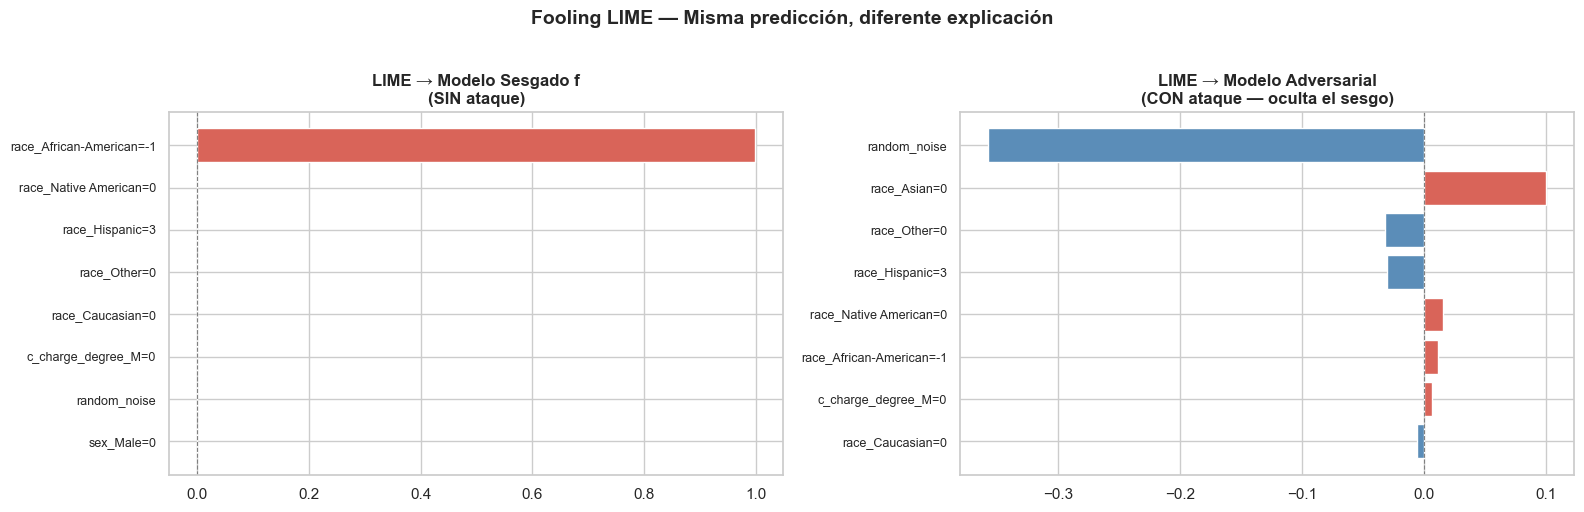

In [31]:
# ==========================================
# 7c. VISUALIZACIÓN COMPARATIVA LIME
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Modelo sesgado ---
top_n = min(8, len(normal_exp))
feats_biased = [f[0][:25] for f in normal_exp[:top_n]]
weights_biased = [f[1] for f in normal_exp[:top_n]]
colors_biased = ['#D96459' if w > 0 else '#5B8DB8' for w in weights_biased]

ax1.barh(range(top_n), weights_biased, color=colors_biased)
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(feats_biased, fontsize=9)
ax1.set_title('LIME → Modelo Sesgado f\n(SIN ataque)', fontweight='bold', fontsize=12)
ax1.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
ax1.invert_yaxis()

# --- Modelo adversarial ---
feats_adv = [f[0][:25] for f in adv_exp[:top_n]]
weights_adv = [f[1] for f in adv_exp[:top_n]]
colors_adv = ['#D96459' if w > 0 else '#5B8DB8' for w in weights_adv]

ax2.barh(range(top_n), weights_adv, color=colors_adv)
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(feats_adv, fontsize=9)
ax2.set_title('LIME → Modelo Adversarial\n(CON ataque — oculta el sesgo)', fontweight='bold', fontsize=12)
ax2.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
ax2.invert_yaxis()

fig.suptitle('Fooling LIME — Misma predicción, diferente explicación',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
# ==========================================
# 7d. LIME — EVALUACIÓN SOBRE TODO EL TEST SET
# ==========================================
print("Generando explicaciones LIME para todo el test set...")

# Limitar a 100 instancias para velocidad
n_explain = min(100, xtest.shape[0])

explanations_lime = []
for i in range(n_explain):
    exp = adv_explainer.explain_instance(xtest[i], adv_lime.predict_proba).as_list()
    explanations_lime.append(exp)
    if (i + 1) % 25 == 0:
        print(f"  Procesadas {i+1}/{n_explain} instancias...")

# Resumen: ¿qué features aparecen en el top-3?
summary = experiment_summary(explanations_lime, features)

print("LIME — Ranking de features en las explicaciones adversariales")
for rank, feat_list in summary.items():
    print(f"\nPosición #{rank} (más importante):")
    sorted_feats = sorted(feat_list, key=lambda x: x[1], reverse=True)
    for feat, pct in sorted_feats[:5]:
        bar = '█' * int(pct * 40)
        print(f"  {feat:30s} {pct*100:5.1f}%  {bar}")

print(f"\nFidelidad global: {adv_lime.fidelity(xtest):.2f}")

Generando explicaciones LIME para todo el test set...
  Procesadas 25/100 instancias...
  Procesadas 50/100 instancias...
  Procesadas 75/100 instancias...
  Procesadas 100/100 instancias...
LIME — Ranking de features en las explicaciones adversariales

Posición #1 (más importante):
  random_noise                   100.0%  ████████████████████████████████████████

Posición #2 (más importante):
  race_Native American            51.0%  ████████████████████
  race_Asian                      40.0%  ████████████████
  race_Other                       5.0%  ██
  race_Hispanic                    3.0%  █
  race_Caucasian                   1.0%  

Posición #3 (más importante):
  race_Asian                      35.0%  ██████████████
  race_Native American            25.0%  ██████████
  race_Other                      16.0%  ██████
  race_Hispanic                   10.0%  ████
  race_Caucasian                   6.0%  ██

Fidelidad global: 0.99


## 9. Análisis de Fidelidad Global

La fidelidad mide qué porcentaje de las predicciones del modelo adversarial coinciden con las del modelo sesgado $f$ en datos reales (in-distribution).

- Fidelidad alta (~1.0) → El ataque funciona: el modelo adversarial toma las mismas decisiones sesgadas, pero LIME explican otra cosa.
- Fidelidad baja → El ataque no funciona bien.

In [33]:
# ==========================================
# 9. ANÁLISIS DE FIDELIDAD
# ==========================================

fidelity_lime = adv_lime.fidelity(xtest)

print("ANÁLISIS DE FIDELIDAD — ¿El ataque funciona?")
print(f"\n  Fidelidad LIME adversarial:  {fidelity_lime:.4f}  ({fidelity_lime*100:.1f}%)")

print(f"\n   Esto significa que el modelo adversarial predice IGUAL que el")
print(f"    modelo racista en {fidelity_lime*100:.1f}% (LIME)")
print(f"    de los datos reales del test set.")
print(f"\n   Pero LIME muestran que la feature más importante es")
print(f"    'random_noise' en lugar de 'race_African-American'.")
print(f"\n    El sesgo racial queda completamente oculto.")

ANÁLISIS DE FIDELIDAD — ¿El ataque funciona?

  Fidelidad LIME adversarial:  0.9879  (98.8%)

   Esto significa que el modelo adversarial predice IGUAL que el
    modelo racista en 98.8% (LIME)
    de los datos reales del test set.

   Pero LIME muestran que la feature más importante es
    'random_noise' en lugar de 'race_African-American'.

    El sesgo racial queda completamente oculto.


In [34]:
# ==========================================
# 9b. COMPARACIÓN DE PREDICCIONES
# ==========================================

# Predicciones de cada modelo
preds_racist = racist_model_f().predict(xtest)
preds_adv_lime = adv_lime.predict(xtest)

print("Distribución de predicciones en el test set:")
print(f"\n  Modelo racista f:")
print(f"    Positivo (no reincidió): {(preds_racist == 1).sum():,}")
print(f"    Negativo (reincidió):    {(preds_racist == 0).sum():,}")

print(f"\n  Adversarial LIME:")
print(f"    Positivo: {(preds_adv_lime == 1).sum():,}")
print(f"    Negativo: {(preds_adv_lime == 0).sum():,}")
print(f"    Coinciden con f: {(preds_adv_lime == preds_racist).sum():,}/{len(preds_racist):,}")



Distribución de predicciones en el test set:

  Modelo racista f:
    Positivo (no reincidió): 594
    Negativo (reincidió):    641

  Adversarial LIME:
    Positivo: 605
    Negativo: 630
    Coinciden con f: 1,220/1,235
